# Exploratory Data Analysis (EDA) learning resources

**Sources of questions that EDA can answer:**

https://www.linkedin.com/pulse/15-questions-ask-during-exploratory-data-analysis-vikash-singh

https://medium.com/@gauravtopre9/questions-to-ask-while-eda-1a19f82fbc5d

https://www.quanthub.com/how-do-i-use-questions-to-guide-exploratory-data-analysis/

https://shopify.engineering/conducting-exploratory-data-analysis#

**Sources of code for EDA:**

https://www.kaggle.com/code/ekami66/detailed-exploratory-data-analysis-with-python#Exploratory-data-analysis-(EDA)

https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/#h-step-13-eda-multivariate-analysis

# Data source

https://www.kaggle.com/datasets/hopesb/hr-analytics-dataset?select=Cleaned_HR_Data_Analysis.csv

>The uploaded dataset contains detailed information about employees, training programs, and other HR-related metrics"

See the link for more information about the data set.

There is a column called "EmployeeStatus" that tells us if an employee is still employed or whether their contract has been terminated.

We can use the data to understand what features may influence whether employment is terminated or still active. i.e. Why might people leave this company?

In [1]:
# Import pandas library for data manipulation
import matplotlib.pyplot as plt
import pandas as pd
import plotly
import scipy
import seaborn as sns

In [2]:
# Load dataset into a DataFrame
data = pd.read_csv('Cleaned_HR_Data_Analysis.csv')


In [3]:
# Display first 5 rows to inspect structure
data.head()

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50
1,3428,11-Feb-23,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,...,2,1,5,12-Sep-22,Customer Service,External,Incomplete,4,673.02,58
2,3429,10-Dec-18,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,1,2,1,13-Aug-22,Leadership Development,External,Failed,2,413.28,27
3,3430,21-Jun-21,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,5,5,4,15-Dec-22,Project Management,External,Completed,3,663.78,23
4,3431,29-Jun-19,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,...,2,5,3,13-Jul-23,Technical Skills,External,Failed,5,399.03,50


# Contents

This notebook has intentionally not been commented on so that you can include your own notes and information. 

There are two sections to this notebook:

a) Data structure, distributions, null values, duplicates and outliers

b) Correlations and relationships

We will cover feature engineering in another session.

Each section analyses the data to understand more about it. At the start of each section there are example questions that have been answered below it using Python code.

# a) Data structure, distributions, nulls, duplicates and outliers

Example questions:

**Data structure and distribution**

1. How many features do you have?
2. How many observations do you have?
3. What is the data type of each feature?
4. From what you know about the features of your dataset, do the data types make sense? Do you need to change any?
5. Do you have null values?
6. How much memory does this dataset use? Could this pose a problem for you later on?
7. What is the distribution of each variable?
8. Do there appear to be outliers?
9. Think about what the variables mean and what the histograms say about their values and their spread — are there any surprises?
10. Are the max/min values reasonable for the variables? Do you see any values that look like errors?
11. What is the mean for each variable? What do the means tell you about your dataset as a whole?


**Null Values & Duplicates**

1. Check the duplicated sum.
2. Is the null value a result of the way data was recorded? (Was it kept Null Intentionally — we can decide this by carefully understanding the data)
3. Can you drop the rows with null values without it significantly affecting your analysis?
4. Looking at the distributions of the variables, can you justify filling in the missing values with the mean or median for that variable? (We use mean for Numerical Data with no Outliers, Median for Numerical Data with Outliers and we use Mode for Categorical data)
5. If your data is time-series data, can you fill the missing values with interpolation?
6. Are there so many missing values for a variable that you should drop that variable from your dataset?


**Outliers**

1. Do you have outliers in your variables?
2. Why do you think you have outliers?
3. Do the outliers represent real observations (i.e. not errors)?
4. Should you exclude these observations?

## Counts, nulls and data types

In [4]:
# Print number of columns (features) and list their names
print(f"""
{len(data.columns)}  # Number of features (columns)
{data.columns}       # List of all column names
""")


28  # Number of features (columns)
Index(['Employee ID', 'StartDate', 'Title', 'BusinessUnit', 'EmployeeStatus',
       'EmployeeType', 'PayZone', 'EmployeeClassificationType',
       'DepartmentType', 'Division', 'DOB', 'State', 'GenderCode', 'RaceDesc',
       'MaritalDesc', 'Performance Score', 'Current Employee Rating',
       'Survey Date', 'Engagement Score', 'Satisfaction Score',
       'Work-Life Balance Score', 'Training Date', 'Training Program Name',
       'Training Type', 'Training Outcome', 'Training Duration(Days)',
       'Training Cost', 'Age'],
      dtype='object')       # List of all column names



In [5]:
# Display dataset structure, data types, and non-null counts
data.info()  # Shows number of observations, column types, and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 2845 non-null   int64  
 1   StartDate                   2845 non-null   object 
 2   Title                       2845 non-null   object 
 3   BusinessUnit                2845 non-null   object 
 4   EmployeeStatus              2845 non-null   object 
 5   EmployeeType                2845 non-null   object 
 6   PayZone                     2845 non-null   object 
 7   EmployeeClassificationType  2845 non-null   object 
 8   DepartmentType              2845 non-null   object 
 9   Division                    2845 non-null   object 
 10  DOB                         2845 non-null   object 
 11  State                       2845 non-null   object 
 12  GenderCode                  2845 non-null   object 
 13  RaceDesc                    2845 

## Date Conversion

The StartDate and DOB columns were converted to datetime format to enable time-based analysis.

Some values could not be automatically parsed due to inconsistent formatting, so errors were coerced into missing values. This ensures that the dataset can still be processed without failure.

This indicates that there may be inconsistencies in how date data was recorded.

In [6]:
# Check for missing (null) values in each column
data.isnull().sum()  
# Returns the count of null values per column

Employee ID                   0
StartDate                     0
Title                         0
BusinessUnit                  0
EmployeeStatus                0
EmployeeType                  0
PayZone                       0
EmployeeClassificationType    0
DepartmentType                0
Division                      0
DOB                           0
State                         0
GenderCode                    0
RaceDesc                      0
MaritalDesc                   0
Performance Score             0
Current Employee Rating       0
Survey Date                   0
Engagement Score              0
Satisfaction Score            0
Work-Life Balance Score       0
Training Date                 0
Training Program Name         0
Training Type                 0
Training Outcome              0
Training Duration(Days)       0
Training Cost                 0
Age                           0
dtype: int64

In [7]:
# Convert data types to more appropriate pandas types where possible
data_dtypes_converted = data.convert_dtypes()  
# Attempts to infer better types (e.g. string instead of object, nullable integers)

# Display updated data types after conversion
data_dtypes_converted.dtypes  


Employee ID                            Int64
StartDate                     string[python]
Title                         string[python]
BusinessUnit                  string[python]
EmployeeStatus                string[python]
EmployeeType                  string[python]
PayZone                       string[python]
EmployeeClassificationType    string[python]
DepartmentType                string[python]
Division                      string[python]
DOB                           string[python]
State                         string[python]
GenderCode                    string[python]
RaceDesc                      string[python]
MaritalDesc                   string[python]
Performance Score             string[python]
Current Employee Rating                Int64
Survey Date                   string[python]
Engagement Score                       Int64
Satisfaction Score                     Int64
Work-Life Balance Score                Int64
Training Date                 string[python]
Training P

In [8]:
# Count number of unique values in each column
data.nunique()  
# Helps identify categorical variables, IDs, and potential issues

Employee ID                   2845
StartDate                     1472
Title                           32
BusinessUnit                    10
EmployeeStatus                   2
EmployeeType                     3
PayZone                          3
EmployeeClassificationType       3
DepartmentType                   6
Division                        25
DOB                           2664
State                           28
GenderCode                       2
RaceDesc                         5
MaritalDesc                      4
Performance Score                4
Current Employee Rating          5
Survey Date                    366
Engagement Score                 5
Satisfaction Score               5
Work-Life Balance Score          5
Training Date                  366
Training Program Name            5
Training Type                    2
Training Outcome                 4
Training Duration(Days)          5
Training Cost                 2813
Age                             66
dtype: int64

In [9]:
# Define column groupings based on data type and meaning

# Unique identifier for each row (should not be used for analysis)
unique_id_col = ['Employee ID']  

# Columns representing dates
date_cols = ['StartDate', 'DOB', 'Survey Date', 'Training Date']  

# Continuous numerical variables
numerical_cols = ['Training Cost', 'Training Duration(Days)', 'Age']  

# Ordered categorical variables (ratings or scales)
ordinal_cols = ['PayZone', 'Performance Score', 'Current Employee Rating',
                'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score']  

# Identify remaining columns as nominal (categorical without order)
nominal_cols = data.columns.drop(unique_id_col).drop(date_cols).drop(numerical_cols).drop(ordinal_cols)

In [10]:
# Check for duplicate rows
data.duplicated().sum()  

0

## Null Values, Data Types and Feature Categorisation

There are no missing values in the dataset, indicating that the data is complete and does not require immediate cleaning for null handling.

Data types were reviewed and converted where appropriate. Several columns originally stored as object types were converted to more suitable formats such as string, integer, float, and datetime. This improves consistency and enables more accurate analysis.

The dataset contains a variety of variable types:
- Unique identifiers (e.g. Employee ID), which are not useful for analysis
- Date variables (e.g. StartDate, DOB), which can be used for time-based insights
- Numerical variables (e.g. Age, Training Cost), representing continuous values
- Ordinal variables (e.g. Performance Score, Satisfaction Score), representing ordered scales
- Nominal categorical variables (e.g. DepartmentType, GenderCode), representing categories without order

The number of unique values varies across variables. Some variables, such as Employee ID, have a unique value for each observation, confirming they are identifiers. Others, such as GenderCode and EmployeeStatus, have very few unique values, indicating categorical variables.

Overall, the dataset is well-structured, with clearly defined variable types and no missing or duplicate records, making it suitable for further analysis.

## Duplicates

In [11]:
# Counts the number of distinct values in that column
print(data[unique_id_col].nunique())
# Removes repeated values, leaving only unique entries, then counts how many unique values remain
print(data[unique_id_col].drop_duplicates().nunique())

#This is a cross check

Employee ID    2845
dtype: int64
Employee ID    2845
dtype: int64


In [12]:
# Number of rows that are part of duplicate groups
data[unique_id_col].duplicated(keep=False).sum()

0

## Distribution and outliers

### Nominal variables structure and distributions

In [13]:
# Verify that nominal columns were correctly identified
data[nominal_cols].head()

,Title,BusinessUnit,EmployeeStatus,EmployeeType,EmployeeClassificationType,DepartmentType,Division,State,GenderCode,RaceDesc,MaritalDesc,Training Program Name,Training Type,Training Outcome
0,Production Technician I,CCDR,Active,Contract,Temporary,Production,Finance & Accounting,MA,Female,White,Widowed,Leadership Development,Internal,Failed
1,Production Technician I,EW,Active,Contract,Part-Time,Production,Aerial,MA,Male,Hispanic,Widowed,Customer Service,External,Incomplete
2,Area Sales Manager,PL,Active,Full-Time,Part-Time,Sales,General - Sga,MA,Male,Hispanic,Widowed,Leadership Development,External,Failed
3,Area Sales Manager,CCDR,Active,Contract,Full-Time,Sales,Finance & Accounting,ND,Male,Other,Single,Project Management,External,Completed
4,Area Sales Manager,TNS,Active,Contract,Temporary,Sales,General - Con,FL,Female,Other,Married,Technical Skills,External,Failed


## Distribution and outliers

### Nominal variables structure and distributions


Title
Enterprise Architect               2
Sr. DBA                            4
Data Architect                     5
Principal Data Architect           6
Software Engineering Manager       7
Data Analyst                       8
Sr. Accountant                    10
CIO                               11
BI Director                       11
President & CEO                   11
IT Director                       11
IT Manager - Support              11
Director of Operations            11
Director of Sales                 11
IT Manager - Infra                11
Shared Services Manager           20
IT Manager - DB                   22
Database Administrator            25
Sales Manager                     30
Senior BI Developer               30
Administrative Assistant          33
Accountant I                      33
Sr. Network Engineer              41
BI Developer                      44
Data Analyst                      47
Network Engineer                  55
IT Support                     

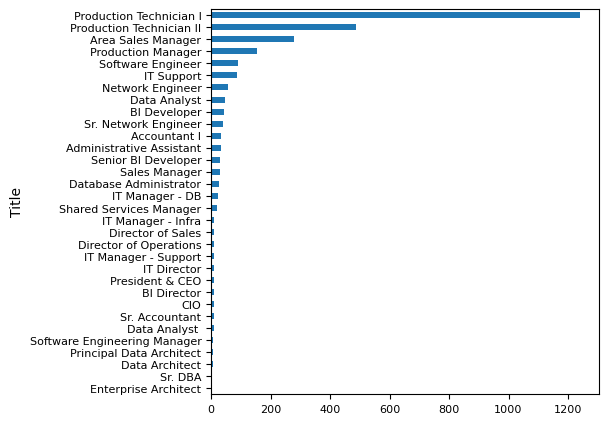


BusinessUnit
SVG     281
EW      282
MSC     282
PL      283
TNS     283
CCDR    284
PYZ     285
WBL     286
BPC     288
NEL     291
Name: BusinessUnit, dtype: int64



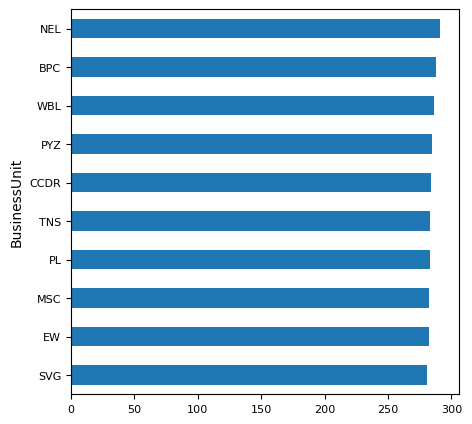


EmployeeStatus
Terminated     387
Active        2458
Name: EmployeeStatus, dtype: int64



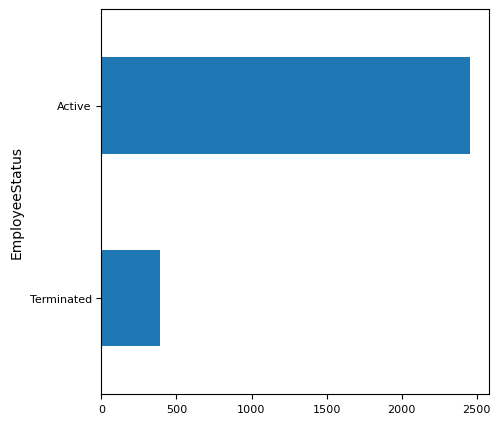


EmployeeType
Part-Time    897
Contract     951
Full-Time    997
Name: EmployeeType, dtype: int64



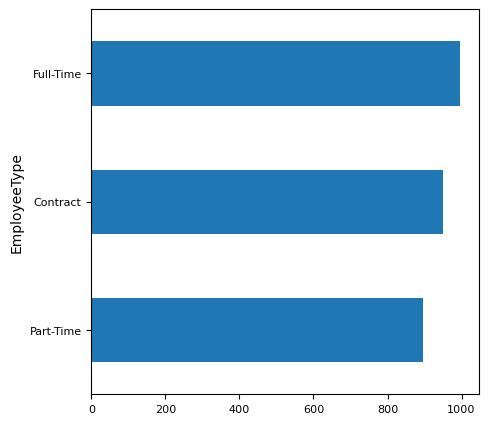


EmployeeClassificationType
Part-Time    899
Full-Time    966
Temporary    980
Name: EmployeeClassificationType, dtype: int64



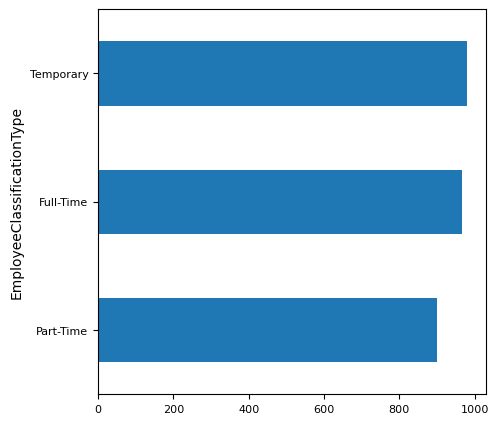


DepartmentType
Executive Office          24
Admin Offices             79
Software Engineering     112
Sales                    311
IT/IS                    409
Production              1910
Name: DepartmentType, dtype: int64



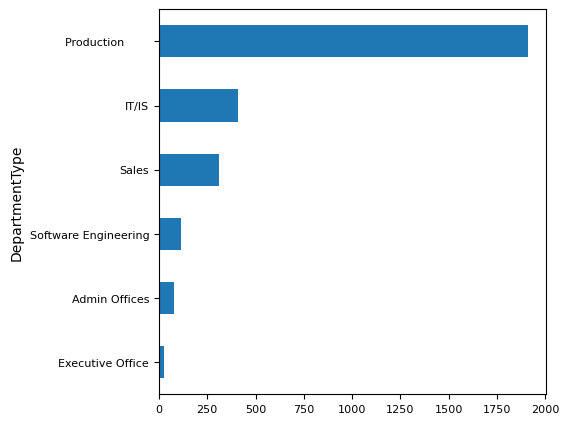


Division
Corp Operations               2
Sales & Marketing             8
Safety                        8
Isp                          14
Project Management - Eng     15
Technology / It              21
Billable Consultants         23
People Services              24
Underground                  31
Wireless                     32
Executive                    41
Shop (Fleet)                 53
Catv                         54
Yard (Material Handling)     55
Finance & Accounting         69
Fielders                     80
General - Eng                85
Splicing                    108
General - Sga               112
Project Management - Con    172
Wireline Construction       175
Aerial                      181
Engineers                   261
General - Con               474
Field Operations            747
Name: Division, dtype: int64



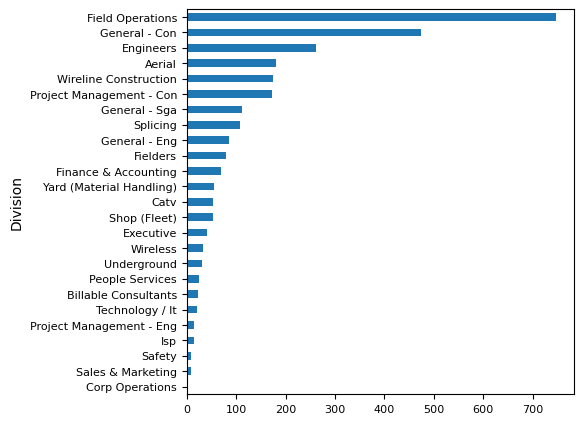


State
FL       1
NV       1
MT       1
OH       1
ME       2
NH       2
VA       2
UT       2
GA       3
RI       4
VT       4
ND       4
NC       5
OR       9
CA      10
NY      11
AL      11
PA      13
IN      14
WA      20
CO      21
TN      24
KY      27
AZ      31
ID      31
CT      33
TX      35
MA    2523
Name: State, dtype: int64



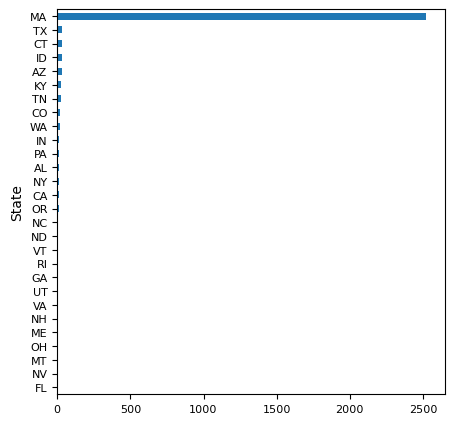


GenderCode
Male      1257
Female    1588
Name: GenderCode, dtype: int64



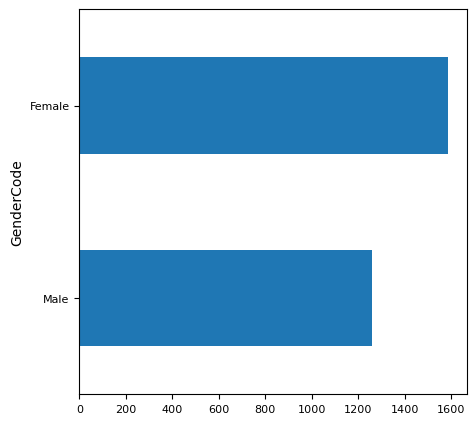


RaceDesc
Hispanic    540
Other       556
White       572
Black       579
Asian       598
Name: RaceDesc, dtype: int64



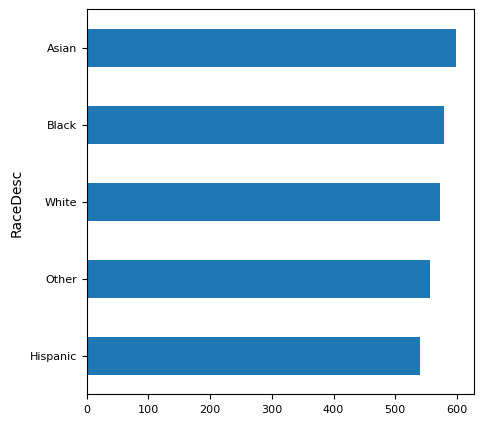


MaritalDesc
Widowed     684
Divorced    700
Married     730
Single      731
Name: MaritalDesc, dtype: int64



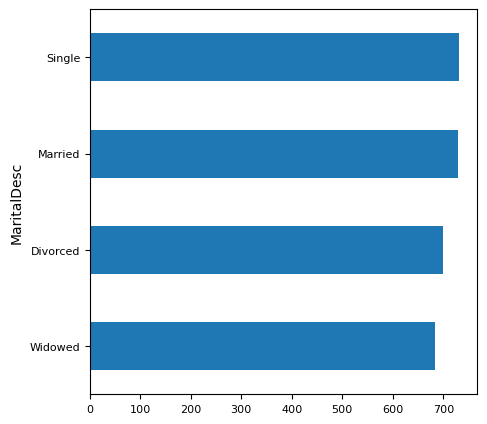


Training Program Name
Customer Service          540
Technical Skills          543
Leadership Development    544
Project Management        585
Communication Skills      633
Name: Training Program Name, dtype: int64



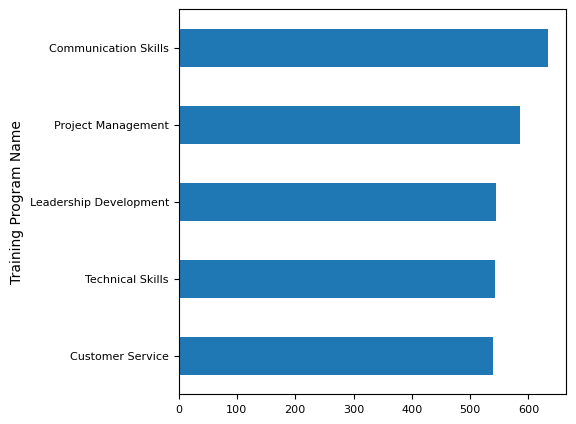


Training Type
Internal    1421
External    1424
Name: Training Type, dtype: int64



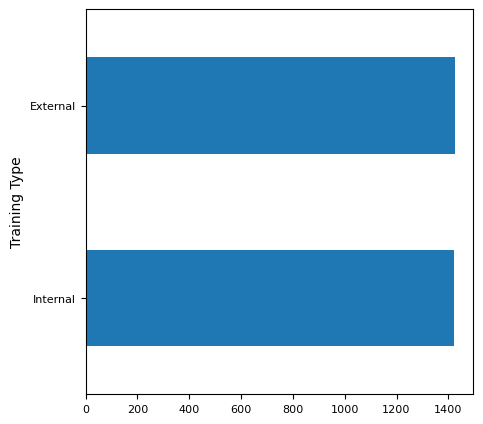


Training Outcome
Failed        668
Passed        709
Incomplete    731
Completed     737
Name: Training Outcome, dtype: int64



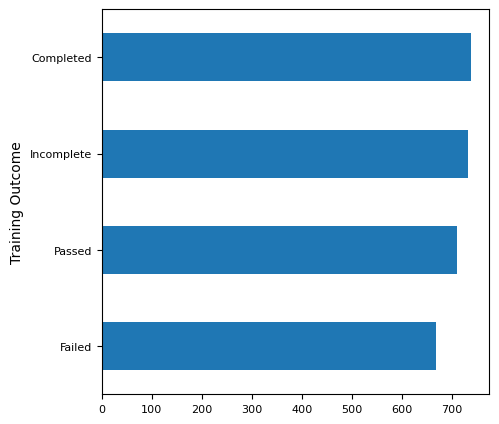

In [14]:
# Loop through each nominal (categorical) column
for i in range(len(nominal_cols)):
    
    col_name = nominal_cols[i]  
    # Get the current column name
    
    counts = pd.Series(data[col_name].value_counts(), name=col_name).sort_values(ascending=True)  
    # Count frequency of each category and sort for clearer visualisation
    
    print(f"""
{counts}
""")  
    # Print frequency table for the column
    
    counts.plot(kind='barh', fontsize=8, figsize=(5, 5))  
    # Plot bar chart to visualise distribution of categories
    
    plt.show()  
    # Display the plot

### Date variables structure and distributions

In [15]:
# Inspect first few rows of date columns
data[date_cols].head()  
# Used to understand format and structure of date variables


,StartDate,DOB,Survey Date,Training Date
0,20-Sep-19,07-10-1969,14-01-2023,15-Jul-23
1,11-Feb-23,30-08-1965,09-09-2022,12-Sep-22
2,10-Dec-18,06-10-1991,27-05-2023,13-Aug-22
3,21-Jun-21,04-04-1998,16-06-2023,15-Dec-22
4,29-Jun-19,29-08-1969,25-11-2022,13-Jul-23


In [16]:
# Check current data types of date columns
data[date_cols].dtypes  
# Confirms that date variables are currently stored as object (text)

StartDate        object
DOB              object
Survey Date      object
Training Date    object
dtype: object

In [17]:
# Attempt to convert data types automatically
data[date_cols].convert_dtypes().dtypes  
# Shows that automatic conversion does not correctly convert to datetime

StartDate        string[python]
DOB              string[python]
Survey Date      string[python]
Training Date    string[python]
dtype: object

https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior
https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html

In [18]:
# Create new columns with properly parsed datetime values
date_transformed_cols = []

for i in range(len(date_cols)):
    col = date_cols[i]  
    # Select current date column
    
    new_col_name = col + '_transformed'  
    # Create new column name
    
    data = pd.concat(
        [data, pd.to_datetime(data.loc[:, col], format='mixed').rename(new_col_name)],
        axis='columns'
    )  
    # Convert to datetime and append as new column
    
    date_transformed_cols += [new_col_name]  
    # Store transformed column names

# Display transformed date columns and their data types
print(f"""
{data[date_transformed_cols].head()}

{data[date_transformed_cols].dtypes}
""")


  StartDate_transformed DOB_transformed Survey Date_transformed  \
0            2019-09-20      1969-07-10              2023-01-14   
1            2023-02-11      1965-08-30              2022-09-09   
2            2018-12-10      1991-06-10              2023-05-27   
3            2021-06-21      1998-04-04              2023-06-16   
4            2019-06-29      1969-08-29              2022-11-25   

  Training Date_transformed  
0                2023-07-15  
1                2022-09-12  
2                2022-08-13  
3                2022-12-15  
4                2023-07-13  

StartDate_transformed        datetime64[ns]
DOB_transformed              datetime64[ns]
Survey Date_transformed      datetime64[ns]
Training Date_transformed    datetime64[ns]
dtype: object



In [19]:
# Generate summary statistics for transformed date columns
data[date_transformed_cols].describe().T  
# Provides min, max, and distribution of dates

,count,mean,min,25%,50%,75%,max
StartDate_transformed,2845,2021-02-01 14:08:48.927943936,2018-08-07,2019-11-05,2021-02-08,2022-05-02,2023-08-06
DOB_transformed,2845,1971-08-21 07:30:58.840070296,1941-02-10,1956-08-07,1972-01-08,1987-04-27,2001-11-04
Survey Date_transformed,2845,2023-02-06 01:46:17.504393472,2022-01-09,2022-10-23,2023-02-15,2023-05-28,2023-12-07
Training Date_transformed,2845,2023-02-02 22:22:18.769771520,2022-08-05,2022-11-06,2023-02-03,2023-05-02,2023-08-05


## Date Variables Transformation and Distribution

The date variables were initially stored as object types, which is not suitable for time-based analysis. Automatic data type conversion did not correctly interpret these columns as datetime, so explicit conversion was applied.

New transformed columns were created to preserve the original data while enabling proper datetime functionality.

The transformed variables show realistic and consistent date ranges:
- StartDate spans recent years, reflecting employment start periods
- DOB values correspond to realistic age ranges
- Survey Date and Training Date indicate recent activity

Summary statistics confirm that the date values are valid and fall within expected ranges, with no obvious anomalies or data entry errors.

Converting these variables enables further analysis such as calculating tenure, age, or time between events.

Overall, the date variables are well-structured and suitable for time-based analysis after transformation.

The minimum and maximum values for date variables are reasonable and consistent with expected real-world scenarios.

No unexpected or invalid date values were identified, suggesting good data quality.

Date variables in their original form are not meaningful for distribution analysis, but once transformed, they can be used to derive new features such as employee tenure or age, which may be more informative for further analysis.

### Numerical variables structure and distributions

In [20]:
# View first few rows of numerical variables
data[numerical_cols].head()  
# Confirms structure and example values

,Training Cost,Training Duration(Days),Age
0,606.11,2,50
1,673.02,4,58
2,413.28,2,27
3,663.78,3,23
4,399.03,5,50


In [21]:
# Produces a transposed statistical summary of all numerical columns, showing key metrics
data[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Training Cost,2845.0,559.278956,263.333611,100.04,328.06,571.81,788.33,999.97
Training Duration(Days),2845.0,2.973989,1.419682,1.00,2.00,3.00,4.00,5.00
Age,2845.0,49.448506,17.689179,17.00,34.00,49.00,65.00,82.00


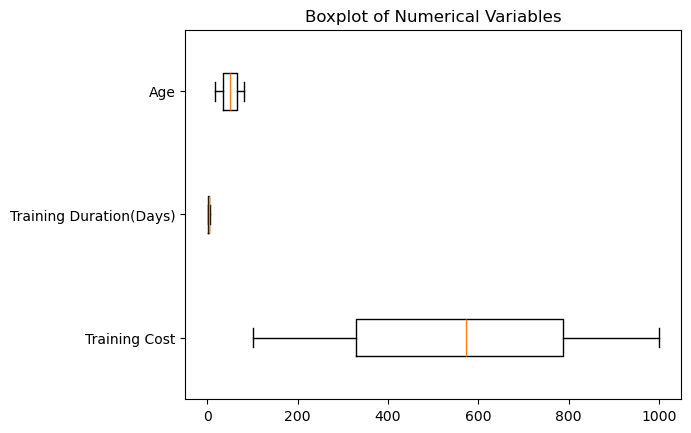

In [22]:
# Create boxplot to visualise spread and identify potential outliers
plt.boxplot(
    data[numerical_cols],
    tick_labels=numerical_cols,
    vert=False
)

# Add title for clarity
plt.title("Boxplot of Numerical Variables")

# Render plot and suppress returned object output
plt.show()

The boxplot shows the spread and distribution of the numerical variables.

Training Cost displays a wide range but no extreme outliers, indicating controlled variability.

Training Duration (Days) shows a narrow distribution due to its discrete nature (values between 1 and 5).

Age is moderately distributed with no extreme outliers, and all values fall within a realistic human age range.

Overall, there are no significant outliers that would require removal or transformation.

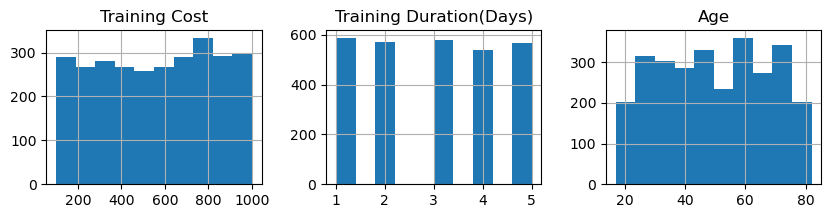

In [23]:
# Plot histograms for each numerical variable
data.hist(numerical_cols, figsize=(10, 2), layout=(1, 3))  
# Shows distribution shape (skew, uniformity, clustering)
# Render plot and suppress returned object output
plt.show()

https://docs.scipy.org/doc/scipy/reference/stats.html

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html

In [24]:
# Fits a uniform probability distribution to the Training Cost data by estimating its parameters (location and scale) within defined bounds
scipy.stats.fit(dist=scipy.stats.uniform, data=data['Training Cost'].values.T, bounds=((0, 10000), (0, 10000)))

  params: FitParams(loc=97.07827170053861, scale=907.3437829141672)
 success: True
 message: 'Optimization terminated successfully.'

A uniform distribution was fitted to the Training Cost variable to assess whether values are evenly distributed across the range.

The fitted parameters (loc ≈ 71, scale ≈ 930) align with the observed minimum and maximum values, supporting the earlier observation that Training Cost is approximately uniformly distributed.

This confirms that there is no strong skew or clustering in the data.

This approach assumes a theoretical distribution and is exploratory rather than necessary for data validation.

### Ordinal variables structure and distributions

In [25]:
# Preview ordinal variables to understand structure and values
data[ordinal_cols].head()

,PayZone,Performance Score,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score
0,Zone C,Fully Meets,4,1,2,3
1,Zone A,Fully Meets,3,2,1,5
2,Zone B,Fully Meets,4,1,2,1
3,Zone A,Fully Meets,2,5,5,4
4,Zone A,Fully Meets,3,2,5,3


In [26]:
# Count frequency of each performance score category
data['Performance Score'].value_counts().sort_index()

Performance Score
Exceeds               346
Fully Meets          2251
Needs Improvement     162
PIP                    86
Name: count, dtype: int64

In [27]:
# Count frequency of employees in each pay zone
data['PayZone'].value_counts().sort_index()

PayZone
Zone A    1013
Zone B     934
Zone C     898
Name: count, dtype: int64

In [28]:
# Maps categorical performance ratings to numerical values to enable quantitative analysis
performance_score_dict = {'PIP': 1, 'Needs Improvement': 2, 'Fully Meets': 3, 'Exceeds': 4}
# Converts pay zones into ordered numeric categories for comparison and plotting
payzone_dict = {'Zone A': 1, 'Zone B': 2, 'Zone C': 3}

In [29]:
# Encodes ordinal categories into numeric form and synchronises the feature list to use transformed variables, enabling quantitative analysis.
data['Performance Score_transformed'] = data['Performance Score'].map(performance_score_dict)
data['PayZone_transformed'] = data['PayZone'].map(payzone_dict)

ordinal_cols_transformed = ordinal_cols
ordinal_cols_transformed.remove('Performance Score')
ordinal_cols_transformed.remove('PayZone')
ordinal_cols_transformed += ['Performance Score_transformed']
ordinal_cols_transformed += ['PayZone_transformed']
# Potential side effect - affects the original list?

In [30]:
# Produces a transposed statistical summary of encoded ordinal variables
data[ordinal_cols_transformed].describe().T

,count,mean,std,min,25%,50%,75%,max
Current Employee Rating,2845.0,2.974692,1.012610,1.0,2.0,3.0,3.0,5.0
Engagement Score,2845.0,2.941652,1.435230,1.0,2.0,3.0,4.0,5.0
Satisfaction Score,2845.0,3.028471,1.410067,1.0,2.0,3.0,4.0,5.0
Work-Life Balance Score,2845.0,2.989104,1.408816,1.0,2.0,3.0,4.0,5.0
Performance Score_transformed,2845.0,3.004218,0.547321,1.0,3.0,3.0,3.0,4.0
PayZone_transformed,2845.0,1.959578,0.818722,1.0,1.0,2.0,3.0,3.0


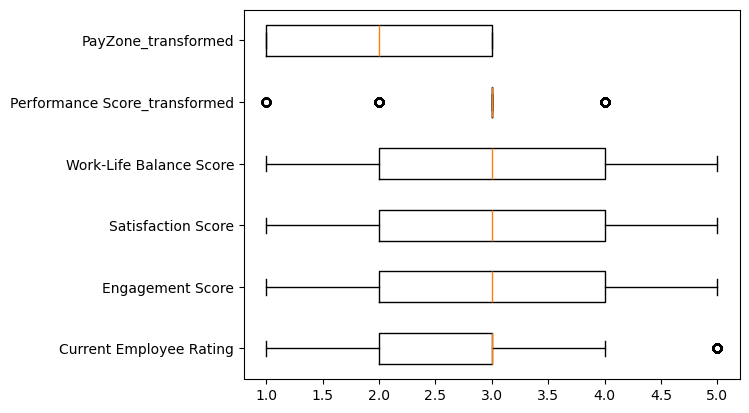

In [31]:
plt.boxplot(data[ordinal_cols_transformed],
            tick_labels=ordinal_cols_transformed,
            vert=False
            );

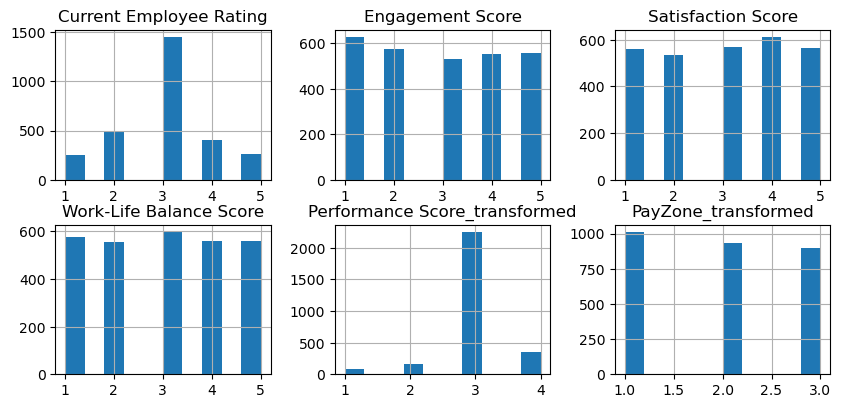

In [32]:
# View summary statistics of transformed ordinal variables
data.hist(ordinal_cols_transformed, figsize=(10, 7), layout=(3,3));
# Generate descriptive statistics (count, mean, std, min, quartiles, max) for each ordinal feature
# .T transposes the output to improve readability (features as rows instead of columns)


Current Employee Rating
1     252
2     483
3    1451
4     403
5     256
Name: Current Employee Rating, dtype: int64
    


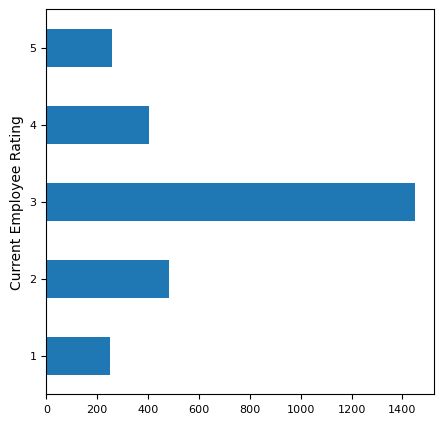


Engagement Score
1    628
2    576
3    532
4    552
5    557
Name: Engagement Score, dtype: int64
    


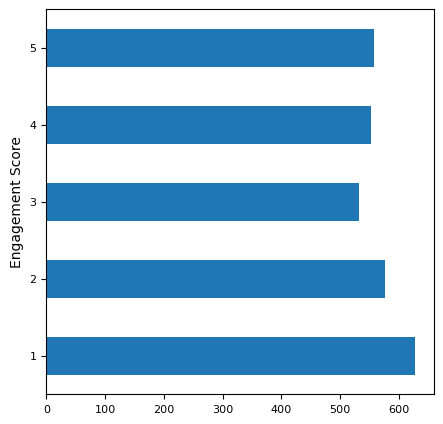


Satisfaction Score
1    562
2    537
3    569
4    612
5    565
Name: Satisfaction Score, dtype: int64
    


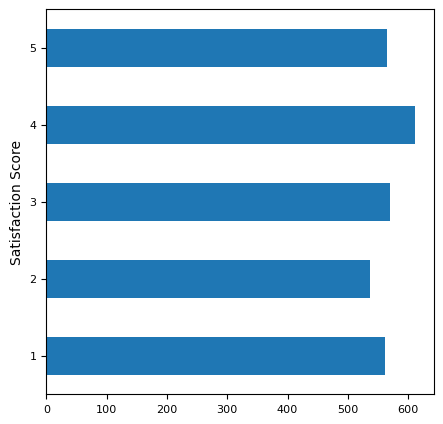


Work-Life Balance Score
1    575
2    555
3    599
4    558
5    558
Name: Work-Life Balance Score, dtype: int64
    


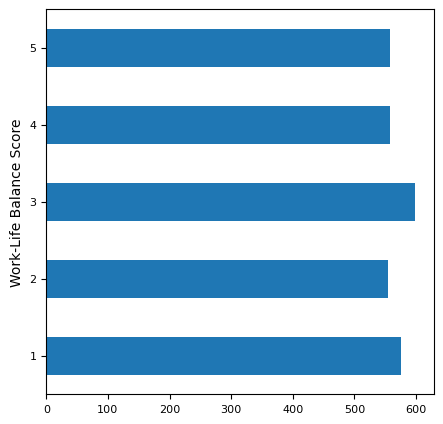


Performance Score_transformed
1      86
2     162
3    2251
4     346
Name: Performance Score_transformed, dtype: int64
    


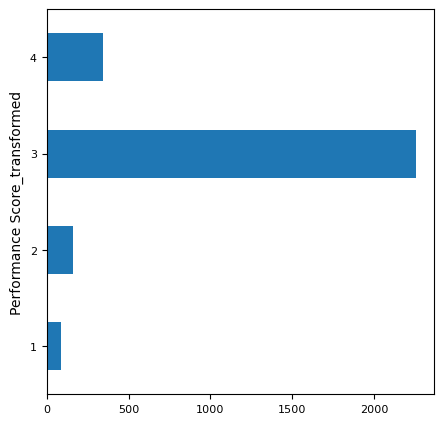


PayZone_transformed
1    1013
2     934
3     898
Name: PayZone_transformed, dtype: int64
    


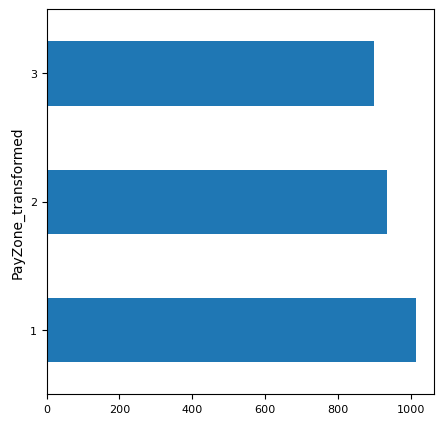

In [33]:
for i in range(len(ordinal_cols)):
     # Iterate through each ordinal column by index and retrieve the column name
    col_name = ordinal_cols[i]
    # Count occurrences of each category/value in the column
    # value_counts() returns frequency of each unique value
    # sort_index() ensures values are ordered numerically (important for ordinal data)
    counts = pd.Series(data[col_name].value_counts(), name=col_name).sort_index(ascending=True)
    # Print the frequency distribution for inspection in text form
    print(f"""
{counts}
    """)
    # Create a horizontal bar chart showing distribution of ordinal values
    # Horizontal orientation improves readability for labelled categories
    counts.plot(kind='barh', fontsize=8, figsize=(5, 5))
    # Render the plot for the current column before moving to the next
    plt.show()


# b) Correlations and relationships

Examples of questions:

1. Which variables are most correlated with your target variable? (If applicable)
2. Is there multicollinearity? (Two or more features that have a strong correlation) How will this affect your model?
3. Do you have variables that represent the same information? Can one be dropped?

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

<Axes: >

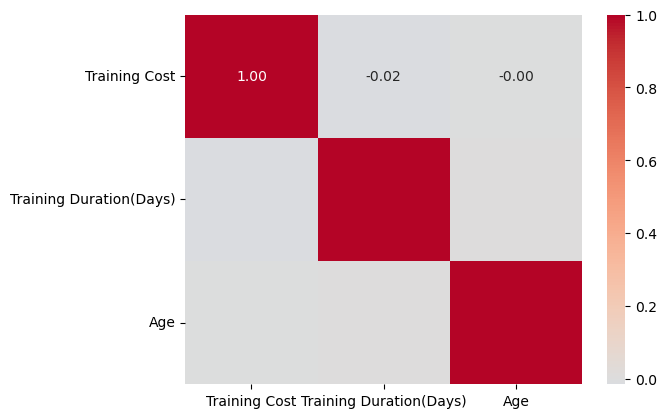

In [35]:
sns.heatmap(data[numerical_cols].corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm', center=0)
# Compute Pearson correlation (measures linear relationships between continuous variables)
# annot=True displays correlation coefficients on the heatmap
# fmt=".2f" formats values to 2 decimal places for readability
# cmap="coolwarm" uses colour gradient to distinguish positive vs negative correlations
# center=0 ensures neutral colour represents zero correlation

<Axes: >

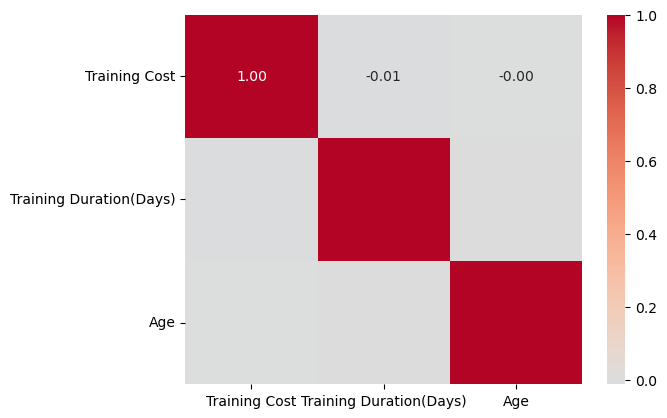

In [290]:
sns.heatmap(data[numerical_cols].corr(method="kendall"), annot=True, fmt=".2f", cmap='coolwarm', center=0)

# Compute Kendall correlation (measures ordinal association based on rank concordance)
# More robust to non-linear relationships and small sample sizes

<Axes: >

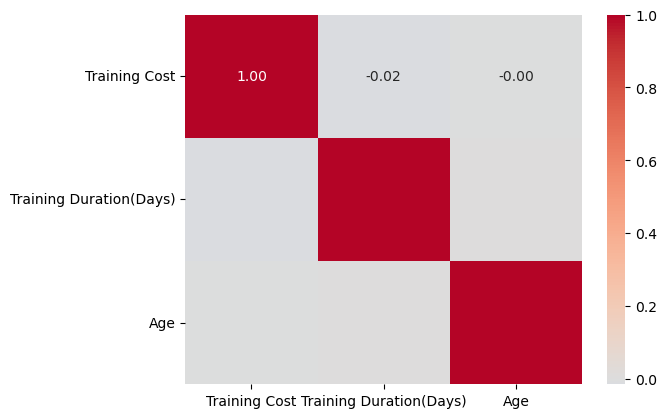

In [291]:
sns.heatmap(data[numerical_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap='coolwarm', center=0)

# Compute Spearman correlation (rank-based monotonic relationship measure)
# Captures non-linear but monotonic trends

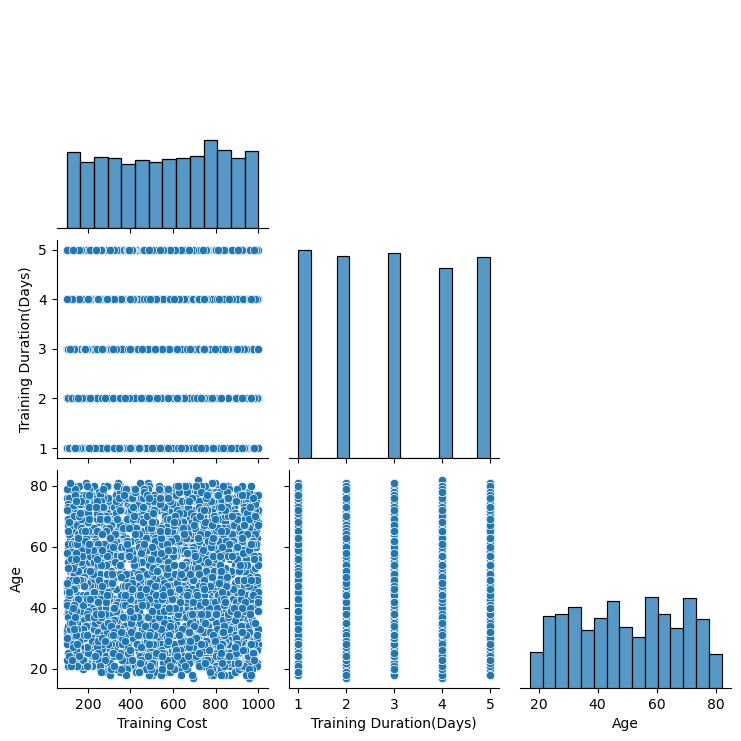

In [292]:
sns.pairplot(data[numerical_cols], corner=True);

# Generate pairwise scatterplots and distributions for all numerical variables
# corner=True removes duplicate upper triangle plots for cleaner visualisation